## Data Preprocessing
<p>prepare raw data so that model learn correctly</p>
<b>Why preprocessing is required?</b>
<ul>
<li>Missing values</li>
<li>Different scales</li>
<li>Categorical features</li>

In [2]:
import pandas as pd
from sklearn.datasets import fetch_openml

titanic=fetch_openml(name="titanic",version=1)
df=titanic.frame


## 1. Understand your data

In [3]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   category
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB


pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

## 2. Removing the use less columns
<b>name, ticket, cabin:</b>
<ul>
<li>Too many unique values (high cardinality)</li>
<li>No strong predictive pattern (noise)</li>
</ul>
<b>Garbage features = bad model</b>

In [4]:

df.drop(columns=["name","ticket","cabin"],inplace=True)

## 3. Separate features and target
<p>axis=1, when working with "colums"<p>
<p>axis=0, when working with "rows"<p>

In [5]:

X=df.drop("survived",axis=1)
y=df["survived"]

## 4. identify different column types
<p>Categorise colums on the basis of there datatype so that we can perform scaling on numerical colums and encoding on categorical data at once.</p>

<b>why?</b>
<p>Different types → different preprocessing:<p>
<ul>
    <li>Numbers → scaling</li>
    <li>Categories → encoding</li>
</ul>

In [6]:
nums_cols=X.select_dtypes(include=["int64","float64"]).columns
cat_cols=X.select_dtypes(include=["object","category"]).columns
print("nums columns:",nums_cols)
print("cat columns:",cat_cols)

nums columns: Index(['pclass', 'age', 'sibsp', 'parch', 'fare', 'body'], dtype='object')
cat columns: Index(['sex', 'embarked', 'boat', 'home.dest'], dtype='object')


## 5. handle missing values
we handle missing values using imputer, it replace the null data with appropiate data derived from the existing data that is not null in the data frame.<br>

<b>Why?</b>
<ul>
    <li>Mean → keeps distribution stable</li>
    <li>Mode → most logical category fill</li>
    <li>ML cannot handle NaN</li>
</ul>

In [7]:
from sklearn.impute import SimpleImputer
nums_imputer=SimpleImputer(strategy="mean")
cat_imputer=SimpleImputer(strategy="most_frequent")

# imputing columns with values
X[nums_cols]=nums_imputer.fit_transform(X[nums_cols])
X[cat_cols]=cat_imputer.fit_transform(X[cat_cols])


## 6. Encoding (REAL WAY, not manual)
<ul>
    <li><b>One-Hot Encoding:</b> Converts categorical variables into binary vectors, avoiding ordinal assumptions.</li>
    <li><b>Drop First:</b> Removes one column to prevent multicollinearity in linear models.</li>
    <li><b>Sparse Output:</b> Uses dense arrays for compatibility with most ML algorithms.</li>
    <li><b>Feature Names:</b> Generates meaningful column names from original categories.</li>
    <li><b>Integration:</b> Concatenates encoded features back to numerical data for complete preprocessing.</li>
</ul>

In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(drop="first",sparse_output=False)

# returns encoded matrix
encoded=encoder.fit_transform(X[cat_cols])
encoded_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out(cat_cols))

X=X.drop(columns=cat_cols)
X=pd.concat([X,encoded_df],axis=1)


## 7. feature scaling

Feature scaling is a crucial preprocessing step in machine learning that standardizes the range of independent variables or features. It ensures that all features contribute equally to the model's performance by transforming them to a common scale, preventing features with larger magnitudes from dominating the learning process. Common techniques include standardization (e.g., using StandardScaler to center data around mean 0 with unit variance) and normalization (e.g., Min-Max scaling to a fixed range like [0,1]). This is especially important for algorithms sensitive to feature scales, such as linear regression, logistic regression, and distance-based methods like KNN or SVM, helping to improve convergence speed and model accuracy.

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X[nums_cols]=scaler.fit_transform(X[nums_cols])

## 8. Splitting data

In [10]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)


## 9. Training Model

In [11]:

from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

## 10. Prediction using model

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error
y_pred = model.predict(X_test)
print(r2_score(y_test, y_pred))
# print(mean_absolute_error(y_test, y_pred))


-5.383762410316748e+21



##  R² Score (Coefficient of Determination)

**Definition:**
R² measures how well the model explains the variance in the target variable.

**Formula:**

```math
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
```

**Where:**

* ( y_i ) = actual value
* ( \hat{y}_i ) = predicted value
* ( \bar{y} ) = mean of actual values

---

##  Variance

**Definition:**
Variance measures how much the data points spread out from the mean.

**Formula:**

```math
\mathrm{Var}(X) = \frac{1}{n} \sum (x_i - \mu)^2
```

**Where:**

* ( x_i ) = data point
* ( \mu ) = mean
* ( n ) = number of data points

---

## Standard Deviation

**Definition:**
Standard deviation is the square root of variance, representing spread in the same unit as data.

**Formula:**

```math
\sigma = \sqrt{\frac{1}{n} \sum (x_i - \mu)^2}
```

---

## Quick Intuition

* **Variance** → spread (squared units)
* **Standard Deviation** → spread (original units)
* **R²** → how well model explains that spread



<hr>

<h2>2. Logistic Regression</h2>

<ul>
  <li>Supervised Machine Learning algorithm</li>
  <li>Used to solve classification problems</li>
  <li>Outcome is binary (0 or 1)</li>
  <li>No missing values are allowed (must be handled during preprocessing)</li>
</ul>

<p>
  We first get a linear continuous result:
  <i>z = b + b1x1 + b2x2 + b3x3 + ... + bnxn</i>
</p>

<p>
  Then we pass this value to the sigmoid function:
</p>

<p>
  <i>y = 1 / (1 + e<sup>-z</sup>)</i>
</p>

<p>
  The output value lies between <b>[0, 1]</b> and forms an 
  <b>S-shaped (sigmoid) curve</b> where 
  <i>x ∈ (-∞, +∞)</i>
</p>

<p><b>Logic:</b></p>

<pre>
if (y > 0.5)
    return 1
else
    return 0
</pre>

<hr>

<h3>Real-World Intuition</h3>

<p>
  Real-world decisions are <b>not linear</b>.
</p>

<p><b>Example:</b></p>

<ul>
  <li>As salary increases → buying probability increases</li>
  <li>But not instantly → it increases gradually</li>
</ul>

In [13]:
# 1.Logistic Regression on the same data set

from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

# 2. Train model
model.fit(X_train,y_train)

# What just happened?
# Model learned patterns like:
# females survived more
# higher class → more survival
# age impact
# It’s finding a decision boundary

LogisticRegression()

In [14]:
# 3. Prediction 
pred=model.predict(X_test)

In [15]:
# testing accuracy
# What just happened?
# Model learned patterns like:
# females survived more
# higher class → more survival
# age impact
# It’s finding a decision boundary

# 4. Accuracy
from sklearn.metrics import accuracy_score
acc=accuracy_score(y_test,pred)
print("accuracy:",acc*100,"%")

accuracy: 95.80152671755725 %


In [16]:
# 5. confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,pred)
print(cm)

#         Predicted
#         0    1
# Actual
# 0      TN   FP
# 1      FN   TP

# TN → correctly predicted dead
# TP → correctly predicted survived
# FP → predicted survived but died 
# FN → predicted died but survived 

[[144   0]
 [ 11 107]]


In [17]:
# 6. Full report
from sklearn.metrics import classification_report
report=classification_report(y_test,pred)
print(report)

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       144
           1       1.00      0.91      0.95       118

    accuracy                           0.96       262
   macro avg       0.96      0.95      0.96       262
weighted avg       0.96      0.96      0.96       262



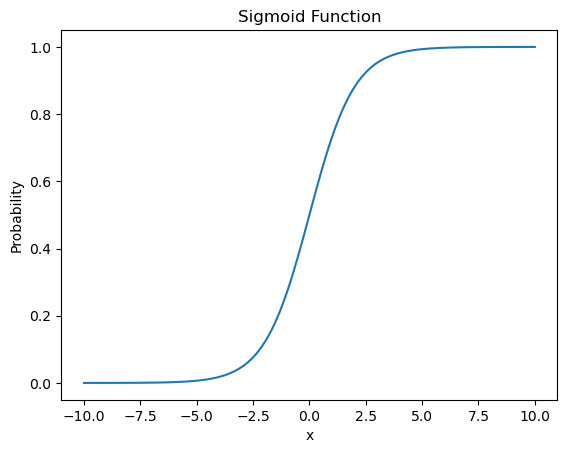

In [18]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("Probability")
plt.title("Sigmoid Function")
plt.show()

<h2>3. K Nearst Neighbours</h2>
<ul>
<li>K nearest neighbours is a supervised ML algorithm used for classification and regression</li>
<li>It predicts the output of a new data point by looking at its k-nearest neighbours</li>
</ul>
<h3><b>Procedure</b><h3>
<ol>
<li>Chooese a value of k (number of neighbours to consider)</li>

<li>
Calculate the distance between the training point and new point
<p>common distances</p>
<ul>
<li>Euclidean</li>
<li>Manhatten</li>
<li>Minkowski</li>
</ul>
</li>

<li>in classification, New point takes the majority class of the neighbours</li>
<li>In regression, New point take the avg of the neighbours</li>
</ol>

<i>Note: K must be odd, k choosen by experiment by testing different values of k, with best accuracy is chooesen.<i>
<p>
Memory-based model
</p>
<li>It stores ALL training data</li>
<li>Slow on large datasets</li>

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
for i in [1,3,5]:
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    acc=accuracy_score(y_test,pred)
    print("accuracy:",acc*100,"%")

accuracy: 87.40458015267176 %
accuracy: 90.07633587786259 %
accuracy: 90.07633587786259 %


<h1>Hyperparameter Tuning (GridSearchCV)</h1>
<p>what is hyperparameters?<p>
<ul>
<li>these are the settings you choose before training</li>
<li>
Examples: 
<ol>
<li>KNN : n_neighbours</li>
<li>Logistic : C</li>
<li>Tree : max_depth</li>
</ol>
<li>Model does not learn this-you tune them</li>
</li> 


<h2>Why "GridSearch"?</h2>
<ul>
<li>Instead of guessing, model find the best value of hyperparameter itself automatically.</li>
<li>Try all possible combinations.</li>
</ul>


In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# define parameter grid
param_grid={
    "n_neighbors":[1,3,5,7,9],
    "weights":["uniform","distance"],
    "metric":["euclidean","manhattan"]
}

# apply GridSearch
grid=GridSearchCV(KNeighborsClassifier(),param_grid,cv=5,scoring="accuracy")
grid.fit(X_train,y_train)

# cross validation: One part is used for validation (testing during training) and the remaining parts are used for training, and this process repeats for all parts

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [1, 3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [21]:
# use best model
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

# High + High + Small gap = GOOD MODEL

Best Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best Score: 0.9025381635907952


In [22]:
# choosing best model
from sklearn.metrics import accuracy_score
model=grid.best_estimator_
pred=model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, pred))

Test Accuracy: 0.9236641221374046


In [23]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(train_acc, test_acc)

0.9961795606494747 0.9236641221374046


<h3>Linear Regression - Limitations</h3>
<ul>
  <li>Assumes linear relationship</li>
  <li>Sensitive to outliers</li>
  <li>Affected by multicollinearity</li>
  <li>Requires feature scaling assumptions</li>
  <li>Poor performance on complex data</li>
</ul>

<h3>Logistic Regression - Limitations</h3>
<ul>
  <li>Linear decision boundary</li>
  <li>Needs feature engineering for non-linearity</li>
  <li>Sensitive to outliers</li>
  <li>Assumes independent features</li>
  <li>Struggles with complex class separation</li>
</ul>

<h3>KNN - Limitations</h3>
<ul>
  <li>Slow prediction on large datasets</li>
  <li>High memory usage</li>
  <li>Sensitive to feature scaling</li>
  <li>Affected by noise (small K)</li>
  <li>Curse of dimensionality</li>
</ul>